## **HandsOn 2** - Sistem Teknologi Multimedia
Dimas Dharma Wicaksono - 122140215

**IMAGE PROCESSING**
Assignment ini berfokus pada topik Image Processing yang menggunakan bahasa pemrograman python

**Kutipan Link AI**
https://chat.qwen.ai/s/d4f77914-f6ac-47ae-acc6-481d77747a75?fev=0.0.86

**Link Repositori GitHub**
https://github.com/HYPExREAL/multimedia_itera_122140215

## **Soal Nomor 1**

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plot

# Baca gambar
image = cv2.imread('Dimas.jpg')

# Ukuran asli
height, width = image.shape[:2]

# Tentukan dimensi terpanjang
max_dim = max(height, width)

# Rasio resize
scale_factor = 1080 / max_dim

# Baru hitung ukuran baru
new_width = int(width * scale_factor)
new_height = int(height * scale_factor)

# Resize gambar
resized_image = cv2.resize(image, (new_width, new_height))

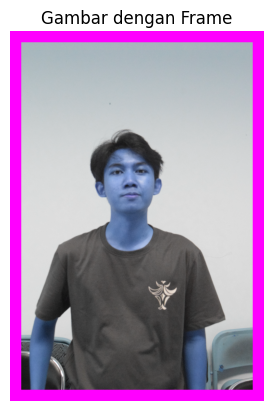

Gambar dengan frame telah disimpan sebagai Dimas_with_frame.jpg


In [24]:
# Misal dua digit terakhir NIM
nim_last_two_digits = 15
frame_thickness = 20 + nim_last_two_digits

# Ukuran baru dengan frame
new_width_with_frame = new_width + 2 * frame_thickness
new_height_with_frame = new_height + 2 * frame_thickness

# Membuat matriks kosong dengan ukuran baru
framed_image = np.zeros((new_height_with_frame, new_width_with_frame, 3), dtype=np.uint8)

# Isi frame dengan warna ungu/magenta (255, 0, 255)
framed_image[:, :] = [255, 0, 255]

# Tempatkan gambar asli di tengah frame
framed_image[frame_thickness:new_height + frame_thickness,
                frame_thickness:new_width + frame_thickness] = resized_image

# Tampilkan gambar dengan frame
plot.imshow(framed_image)
plot.title('Gambar dengan Frame')
plot.axis('off') 
plot.show()

# Simpan gambar hasil
output_filename = 'Dimas_with_frame.jpg'
cv2.imwrite(output_filename, framed_image)
print(f"Gambar dengan frame telah disimpan sebagai {output_filename}")

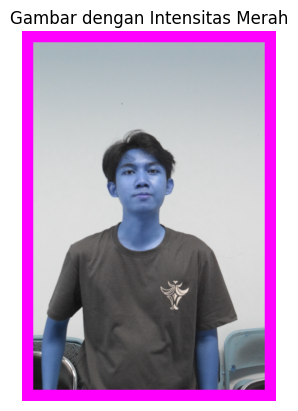

Gambar dengan intensitas merah telah disimpan sebagai Dimas_with_red_intensity.jpg


In [25]:
# Pisahkan channel RGB
b, g, r = cv2.split(framed_image)

# Identifikasi bagian tengah gambar
mid_x = new_width // 2
mid_y = new_height // 2

# Area tengah (misal: ±10% dari pusat)
center_width = int(new_width * 0.1)
center_height = int(new_height * 0.1)

# Naikkan intensitas channel merah di area tengah
r[mid_y - center_height:mid_y + center_height,
    mid_x - center_width:mid_x + center_width][
        (r[mid_y - center_height:mid_y + center_height,
            mid_x - center_width:mid_x + center_width] >= 50) &
        (r[mid_y - center_height:mid_y + center_height,
            mid_x - center_width:mid_x + center_width] <= 150)
    ] += 3

# Gabungkan kembali channel RGB
framed_image = cv2.merge((b, g, r))

# Tampilkan gambar dengan intensitas merah yang ditingkatkan
plot.imshow(framed_image)
plot.title('Gambar dengan Intensitas Merah')
plot.axis('off')
plot.show()

# Simpan gambar hasil
output_filename = 'Dimas_with_red_intensity.jpg'
cv2.imwrite(output_filename, framed_image)
print(f"Gambar dengan intensitas merah telah disimpan sebagai {output_filename}")


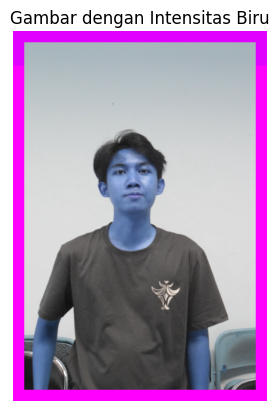

True

In [26]:
# Pisahkan channel RGB
b, g, r = cv2.split(framed_image)

# Area atas (misal: 10% dari bagian atas)
top_height = int(new_height * 0.1)

# Turunkan intensitas channel biru di area atas
b[:top_height, :][(b[:top_height, :] >= 200) & (b[:top_height, :] <= 255)] -= 30

# Gabungkan kembali channel RGB
framed_image = cv2.merge((b, g, r))

# Tampilkan gambar dengan intensitas biru yang diturunkan
plot.imshow(framed_image)
plot.title('Gambar dengan Intensitas Biru')
plot.axis('off')
plot.show()

# Simpan gambar hasil
output_filename = 'Dimas_with_blue_intensity.jpg'
cv2.imwrite(output_filename, framed_image)

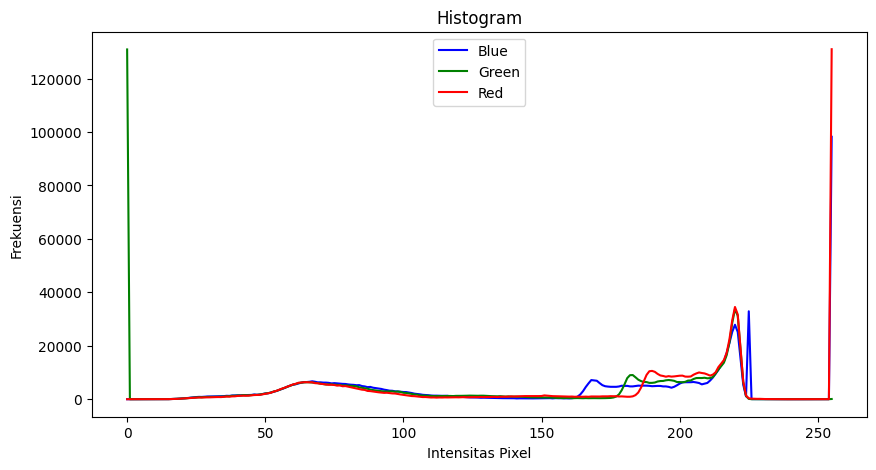

In [27]:
import matplotlib.pyplot as plt

# Hitung histogram untuk setiap channel RGB
hist_b = cv2.calcHist([framed_image], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([framed_image], [1], None, [256], [0, 256])
hist_r = cv2.calcHist([framed_image], [2], None, [256], [0, 256])

# Plot histogram
plt.figure(figsize=(10, 5))
plt.title("Histogram")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.plot(hist_b, color='blue', label='Blue')
plt.plot(hist_g, color='green', label='Green')
plt.plot(hist_r, color='red', label='Red')
plt.legend()
plt.show()

## **Soal Nomor 2**

In [28]:
import cv2

# Baca gambar dalam format RGB
image = cv2.imread('Dimas.jpg')

# Konversi ke grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

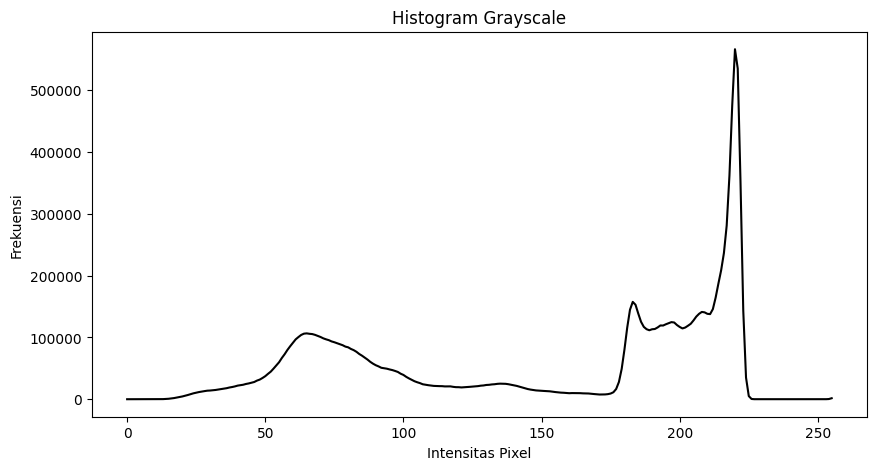

In [29]:
import matplotlib.pyplot as plt

# Hitung histogram
hist_gray = cv2.calcHist([gray_image], [0], None, [256], [0, 256])

# Plot histogram
plt.figure(figsize=(10, 5))
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.plot(hist_gray, color='black')
plt.show()

In [30]:
# Normalisasi intensitas
normalized_image = cv2.normalize(gray_image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

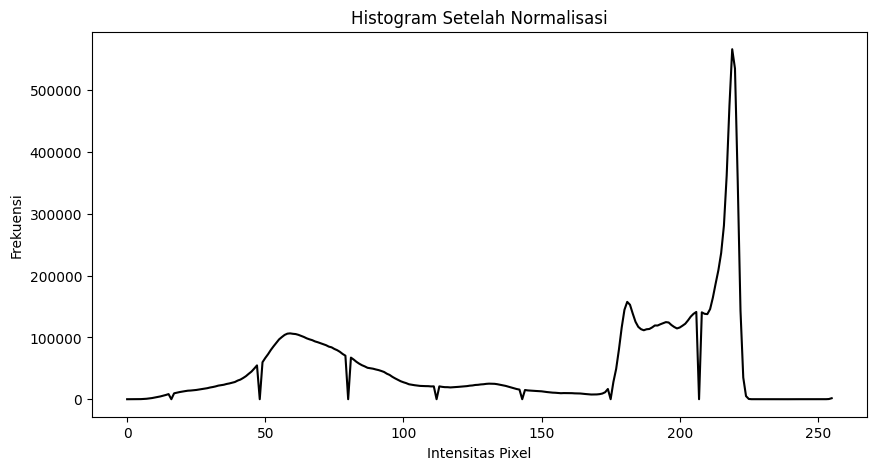

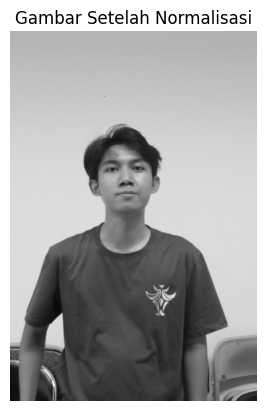

True

In [31]:
# Hitung histogram setelah normalisasi
hist_normalized = cv2.calcHist([normalized_image], [0], None, [256], [0, 256])

# Plot histogram
plt.figure(figsize=(10, 5))
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.plot(hist_normalized, color='black')
plt.show()

# Tampilkan gambar hasil normalisasi
plot.imshow(normalized_image, cmap='gray')
plot.title("Gambar Setelah Normalisasi")
plot.axis('off')
plot.show()

# Simpan gambar hasil normalisasi
output_filename = 'Dimas_normalized.jpg'
cv2.imwrite(output_filename, normalized_image)

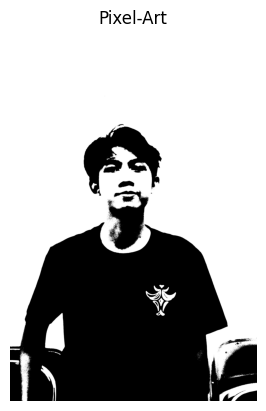

True

In [32]:
# Membuat pixel-art
pixel_art = np.where(normalized_image < 128, 0, 255).astype(np.uint8)

# Tampilkan gambar pixel-art
plot.imshow(pixel_art, cmap='gray')
plot.title("Pixel-Art")
plot.axis('off')
plot.show()

# Simpan gambar pixel-art
output_filename = 'Dimas_pixel_art.jpg'
cv2.imwrite(output_filename, pixel_art)

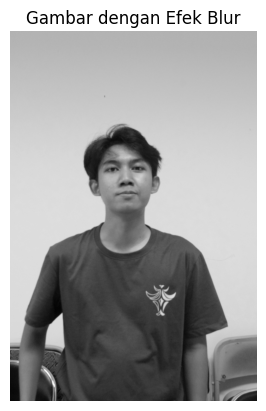

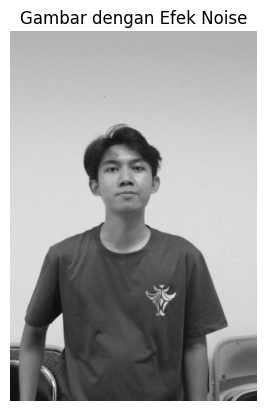

True

In [33]:
# Efek Blur
blurred_image = cv2.GaussianBlur(normalized_image, (5, 5), 0)

# Efek Noise
noise = np.random.normal(0, 20, normalized_image.shape).astype(np.int16)
noisy_image = cv2.add(normalized_image.astype(np.int16), noise).clip(0, 255).astype(np.uint8)

# Tampilkan gambar hasil efek blur
plot.imshow(blurred_image, cmap='gray')
plot.title('Gambar dengan Efek Blur')
plot.axis('off')
plot.show()

# Simpan gambar hasil efek blur
output_filename = 'Dimas_blurred.jpg'
cv2.imwrite(output_filename, blurred_image)

# Tampilkan gambar hasil efek noise
plot.imshow(noisy_image, cmap='gray')
plot.title('Gambar dengan Efek Noise')
plot.axis('off')
plot.show()

# Simpan gambar hasil efek noise
output_filename = 'Dimas_noisy.jpg'
cv2.imwrite(output_filename, noisy_image)

## **Soal Nomor 3**

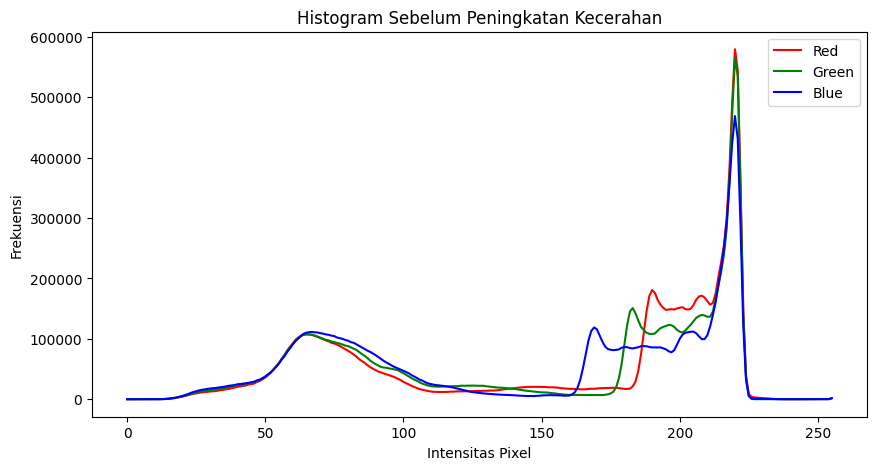

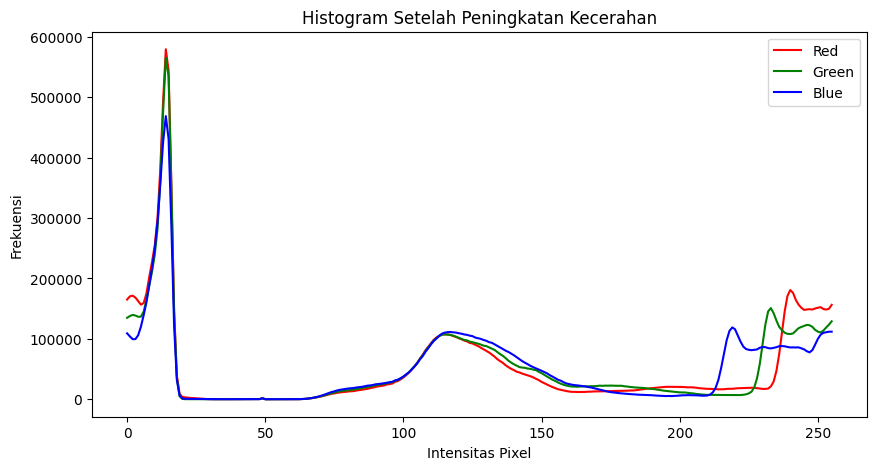

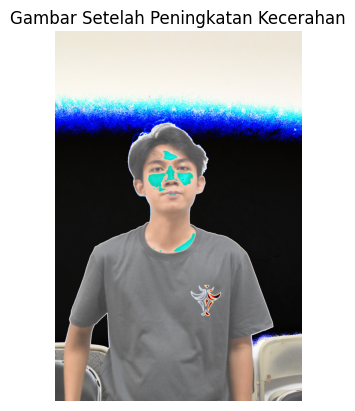

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
image = cv2.imread('Dimas.jpg')

# Konversi gambar ke format RGB (OpenCV membaca dalam BGR)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Naikkan kecerahan
brightness_increase = 50
brightened_image = np.clip(rgb_image + brightness_increase, 0, 255).astype(np.uint8)

# Fungsi untuk menampilkan histogram
def plot_histogram(image, title):
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.xlabel("Intensitas Pixel")
    plt.ylabel("Frekuensi")
    
    # Hitung histogram untuk setiap channel
    for i, color in enumerate(['Red', 'Green', 'Blue']):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        plt.plot(hist, color=color, label=color)
    plt.legend()
    plt.show()

# Tampilkan histogram sebelum dan sesudah peningkatan kecerahan
plot_histogram(rgb_image, "Histogram Sebelum Peningkatan Kecerahan")
plot_histogram(brightened_image, "Histogram Setelah Peningkatan Kecerahan")

# Tampilkan gambar hasil
plt.imshow(brightened_image)
plt.title("Gambar Setelah Peningkatan Kecerahan")
plt.axis('off')
plt.show()

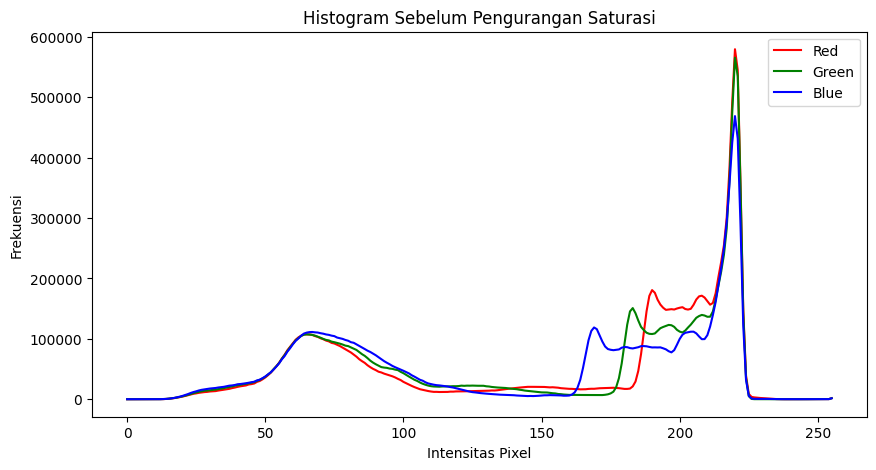

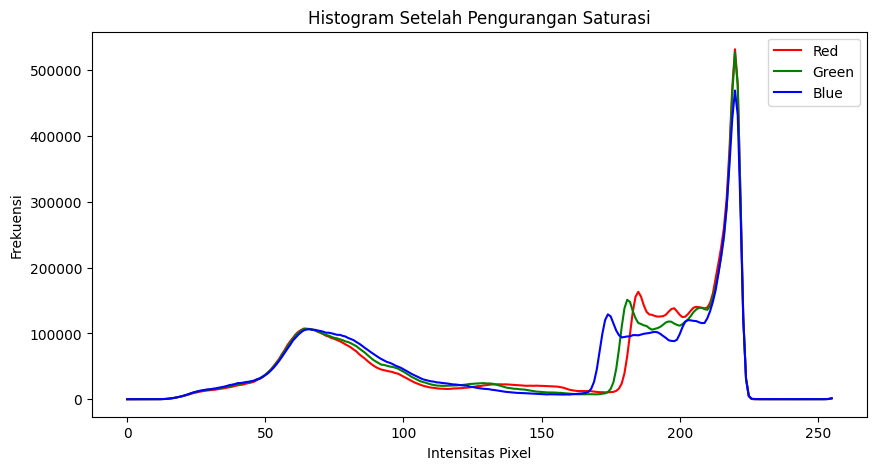

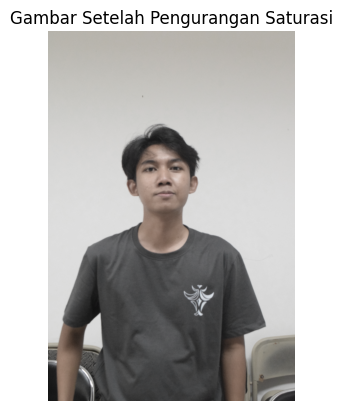

In [35]:
# Turunkan saturasi
saturation_reduction_factor = 0.5  # Faktor pengurangan saturasi
grayscale_avg = np.mean(rgb_image, axis=2, keepdims=True)  # Rata-rata dari R, G, B
desaturated_image = saturation_reduction_factor * rgb_image + (1 - saturation_reduction_factor) * grayscale_avg

# Konversi kembali ke uint8
desaturated_image = desaturated_image.astype(np.uint8)

# Tampilkan histogram sebelum dan sesudah pengurangan saturasi
plot_histogram(rgb_image, "Histogram Sebelum Pengurangan Saturasi")
plot_histogram(desaturated_image, "Histogram Setelah Pengurangan Saturasi")

# Tampilkan gambar hasil
plt.imshow(desaturated_image)
plt.title("Gambar Setelah Pengurangan Saturasi")
plt.axis('off')
plt.show()

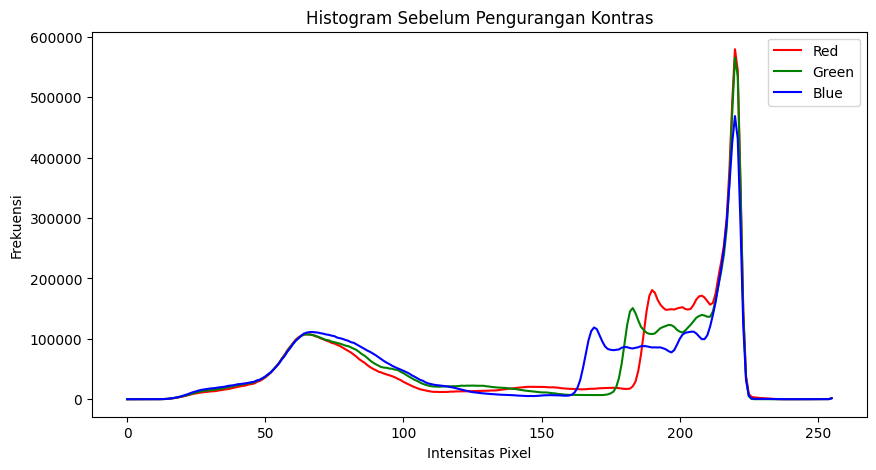

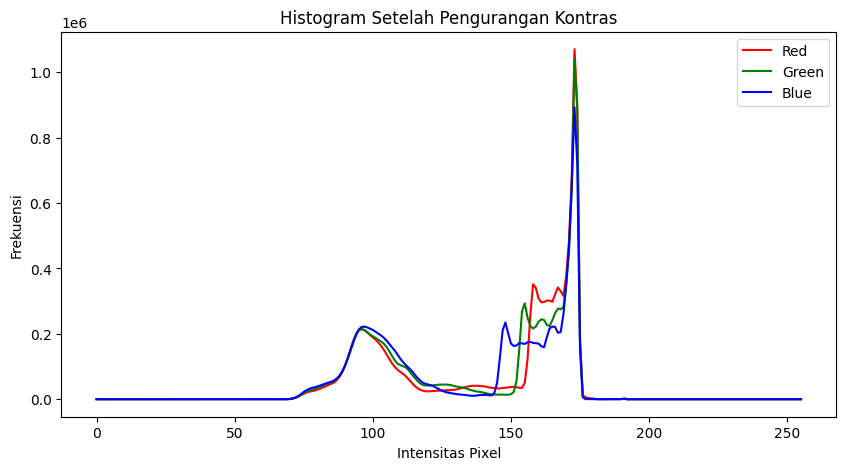

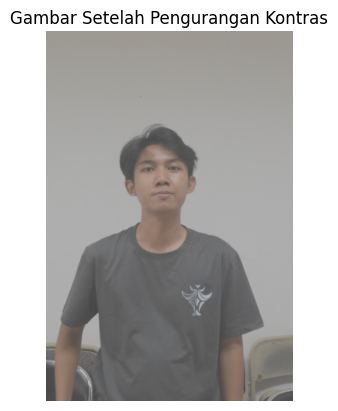

In [36]:
# Turunkan kontras
contrast_reduction_factor = 0.5  # Faktor pengurangan kontras
normalized_image = rgb_image / 255.0  # Normalisasi ke [0, 1]
low_contrast_image = contrast_reduction_factor * normalized_image + (1 - contrast_reduction_factor) * 0.5  # Interpolasi ke nilai tengah
low_contrast_image = (low_contrast_image * 255).astype(np.uint8)

# Tampilkan histogram sebelum dan sesudah pengurangan kontras
plot_histogram(rgb_image, "Histogram Sebelum Pengurangan Kontras")
plot_histogram(low_contrast_image, "Histogram Setelah Pengurangan Kontras")

# Tampilkan gambar hasil
plt.imshow(low_contrast_image)
plt.title("Gambar Setelah Pengurangan Kontras")
plt.axis('off')
plt.show()